In [7]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rcParams.update({"axes.grid":False})

from ContactMechanics import PeriodicFFTElasticHalfSpace
from SurfaceTopography import Topography
from ContactMechanics.Factory import make_system

import numpy as np


 #### Resolution
 You can choose an arbitrary nb_grid_pts (e.g. this of your measurement), but the fourier transformation algorithm FFT is particularly effective on powers of two.

In [8]:
nx, ny = 256, 256

physical_sizes

In [9]:
sx,sy= 2*np.pi, 2*np.pi 

generate a bisinusoidal topography

In [10]:
x = np.arange(nx).reshape(-1,  1) * sx / nx
y = np.arange(ny).reshape( 1, -1) * sy / ny
sinewave_amplitude = 0.1
h = sinewave_amplitude  * np.sin(x) * np.sin(y) 

topography = Topography(h, physical_sizes=(sx, sy), periodic=True)

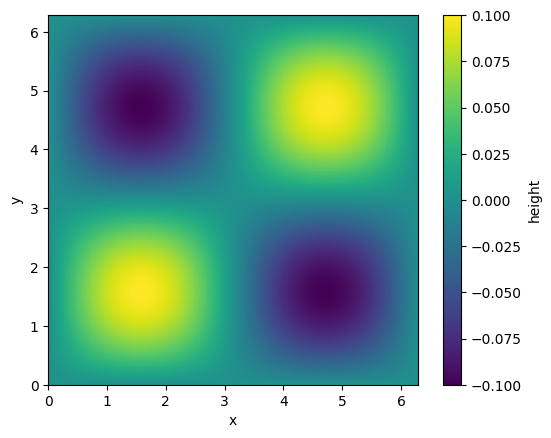

In [11]:
fig, ax = plt.subplots()

X, Y = np.meshgrid(np.arange(nx+1) * sx/nx, np.arange(ny+1) * sy/ny, indexing='ij') 
pcm = ax.pcolormesh(X,Y, topography.heights())
cb = plt.colorbar(pcm,ax= ax, label= "height")

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_aspect(1)

## Substrate with finite thickness

Text(0.5, 0, 'forces')

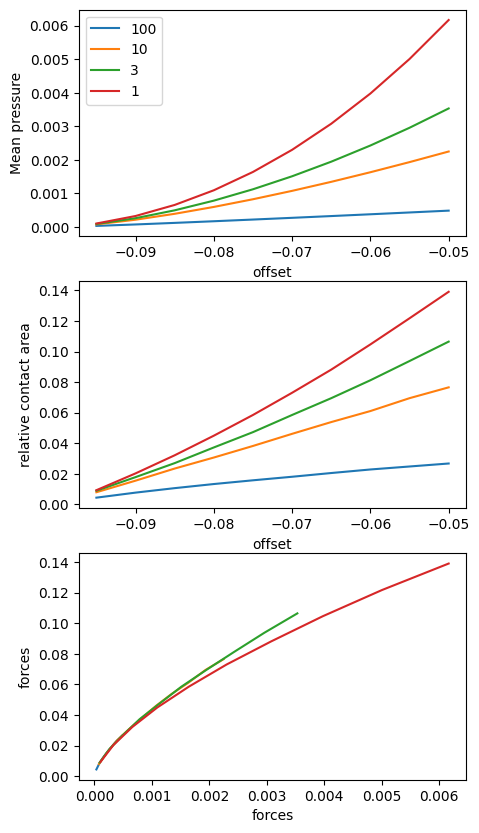

In [12]:
fig, (ax, axa, axaf) = plt.subplots(3, 1, figsize=(5,10))
E = 1 
poisson=0.3
for thickness in [100, 10, 3,1]:
    substrate = PeriodicFFTElasticHalfSpace(nb_grid_pts=(nx,ny), young=E, poisson=poisson, thickness=thickness, physical_sizes = (sx, sy))
    system = make_system(substrate=substrate, surface=topography)

    disps0 = None # you don't have a 
    
    forces = []
    areas = []

    offsets = - sinewave_amplitude + np.linspace(0.1, 1,10) * 0.05
    for offset in offsets :
        sol = system.minimize_proxy(offset=offset, initial_displacements = disps0, pentol= 1e-9, maxiter = 100000)
        assert sol.success, "{}".format(sol)
        disps0 = system.disp
        forces.append(system.compute_normal_force() / (sx * sy))
        areas.append(system.compute_contact_area() / (sx * sy))
    lf, = ax.plot(offsets, forces, label=f'{thickness}')
    la, = axa.plot(offsets, areas, label=f'{thickness}')
    la, = axaf.plot(forces, areas, label=f'{thickness}')

        
ax.legend()
ax.set_ylabel("Mean pressure")
axa.set_ylabel("relative contact area")
axa.set_xlabel('offset')
ax.set_xlabel('offset')

axaf.set_ylabel('forces')
axaf.set_xlabel('forces')
